# Kernel Classification Project
**Quantum Machine Learning and Artificial Intelligence**

---
This notebook walks through all five project parts end-to-end:
- **Part 1** — Theoretical background and dataset overview
- **Part 2** — Quantum feature map circuits
- **Part 3** — Kernel matrix computation and heatmaps
- **Part 4** — QSVM vs classical SVM benchmark
- **Part 5** — Angle embedding with PCA

In [1]:
import os, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')
os.makedirs('results', exist_ok=True)
%matplotlib inline
plt.rcParams.update({'figure.dpi': 110, 'font.family': 'DejaVu Sans'})
print('Environment ready.')

Environment ready.


---
## Part 1 — Theoretical Background

### Key Concepts

**Quantum feature map** $U(x)$: a parametrized quantum circuit that maps a classical vector $x ∈ Rᵈ$ to a quantum state:

$$|\phi(x)\rangle = U(x)|0\rangle$$

**Quantum kernel**: the squared overlap (fidelity) between two encoded states:

$$K(x, z) = |\langle\phi(x)|\phi(z)\rangle|^2$$

This is estimated via the **compute-uncompute** circuit:
1. Prepare $|\phi(x)\rangle$ by running $U(x)$
2. Apply the inverse $U(z)^\dagger$
3. Measure the probability of the all-zeros bitstring $|0\rangle^{\otimes n}$
4. That probability $= |\langle\phi(x)|\phi(z)\rangle|^2$

**Why does this matter?**  
The kernel matrix $K_{ij} = K(x_i, x_j)$ is symmetric and positive semi-definite, so it drops directly into sklearn's `SVC(kernel='precomputed')`. The SVM then finds the maximum-margin hyperplane in the quantum Hilbert space without ever computing the full $2^n$-dimensional state vector explicitly.

### Why not use all 30 features?

The breast cancer dataset has 30 features. Running a **30-qubit** quantum circuit on a classical simulator is computationally intractable:

| Qubits | State vector size | Memory needed |
|--------|-------------------|---------------|
| 2 | $2^2 = 4$ amplitudes | negligible |
| 10 | $2^{10} = 1{,}024$ | ~16 KB |
| 20 | $2^{20} \approx 10^6$ | ~16 MB |
| **30** | $2^{30} \approx 10^9$ | **~16 GB** |

Beyond memory, the kernel matrix for $n$ training samples requires $O(n^2)$ full circuit evaluations. At 30 qubits, each evaluation is already slow, and with hundreds of samples the total time is measured in days, not seconds.

**The standard solution in QSVM research:** reduce the feature space to 2–4 dimensions before encoding. This project uses two strategies:

- **Parts 2–4:** select the 2 raw features with the highest training-set variance. Features stay interpretable — they are real, named measurements.
- **Part 5:** apply PCA, project onto the top 2 principal components, and use those as angle-encoding rotation angles. This is where PCA enters the project.

In [2]:
# ── Dataset ────────────────────────────────────────────────────
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA

data = load_breast_cancer()
X_raw, y_raw = data.data, np.where(data.target == 0, -1, 1)

print('Breast Cancer Wisconsin Dataset')
print(f'  Samples  : {len(X_raw)}')
print(f'  Features : {X_raw.shape[1]}')
print(f'  Malignant: {(y_raw == -1).sum()}  |  Benign: {(y_raw == 1).sum()}')
pd.DataFrame(X_raw, columns=data.feature_names).describe().round(2)

Breast Cancer Wisconsin Dataset
  Samples  : 569
  Features : 30
  Malignant: 212  |  Benign: 357


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,...,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00
mean,14.13,19.29,91.97,654.89,0.10,0.10,0.09,0.05,0.18,0.06,...,16.27,25.68,107.26,880.58,0.13,0.25,0.27,0.11,0.29,0.08
std,3.52,4.30,24.30,351.91,0.01,0.05,0.08,0.04,0.03,0.01,...,4.83,6.15,33.60,569.36,0.02,0.16,0.21,0.07,0.06,0.02
min,6.98,9.71,43.79,143.50,0.05,0.02,0.00,0.00,0.11,0.05,...,7.93,12.02,50.41,185.20,0.07,0.03,0.00,0.00,0.16,0.06
25%,11.70,16.17,75.17,420.30,0.09,0.06,0.03,0.02,0.16,0.06,...,13.01,21.08,84.11,515.30,0.12,0.15,0.11,0.06,0.25,0.07
50%,13.37,18.84,86.24,551.10,0.10,0.09,0.06,0.03,0.18,0.06,...,14.97,25.41,97.66,686.50,0.13,0.21,0.23,0.10,0.28,0.08
75%,15.78,21.80,104.10,782.70,0.11,0.13,0.13,0.07,0.20,0.07,...,18.79,29.72,125.40,1084.00,0.15,0.34,0.38,0.16,0.32,0.09
max,28.11,39.28,188.50,2501.00,0.16,0.35,0.43,0.20,0.30,0.10,...,36.04,49.54,251.20,4254.00,0.22,1.06,1.25,0.29,0.66,0.21


In [3]:
# ── Shared preprocessing for Parts 2, 3, 4  (NO PCA) ──────────
#
# Strategy: select the 2 raw features with the highest variance on the
# training set. Variance is computed on X_tr only — no data leakage.
# These features are used directly as qubit rotation angles after scaling.
#
N_FEATURES = 2    # number of qubits = number of features encoded
MAX_TRAIN  = 80   # quantum kernel is O(n²) circuit evaluations — cap for speed
MAX_TEST   = 40

X_tr_full, X_te_full, y_tr_full, y_te_full = train_test_split(
    X_raw, y_raw, test_size=0.20, random_state=42, stratify=y_raw
)

# Feature selection by variance (training set only)
feat_vars  = X_tr_full.var(axis=0)
top_idx    = np.argsort(feat_vars)[::-1][:N_FEATURES]
feat_names = data.feature_names[top_idx]
print(f'Selected features: {list(feat_names)}')
print(f'Their variances  : {feat_vars[top_idx].round(0)}')

X_tr2, X_te2 = X_tr_full[:, top_idx], X_te_full[:, top_idx]

# Subsample training set for quantum kernel speed
rng     = np.random.default_rng(42)
idx_q   = rng.choice(len(X_tr2), size=MAX_TRAIN, replace=False)
X_tr_q  = X_tr2[idx_q]
y_tr_q  = y_tr_full[idx_q]
X_te_q  = X_te2[:MAX_TEST]
y_te_q  = y_te_full[:MAX_TEST]

# Scale to [0, π]  — maps each feature to a valid rotation angle
scaler  = MinMaxScaler(feature_range=(0, np.pi))
X_tr_q  = scaler.fit_transform(X_tr_q)
X_te_q  = scaler.transform(X_te_q)

print(f'\nTrain (quantum): {len(X_tr_q)} samples  |  Test: {len(X_te_q)} samples')
print(f'Feature range after scaling: [{X_tr_q.min():.3f}, {X_tr_q.max():.3f}] rad')

Selected features: [np.str_('worst area'), np.str_('mean area')]
Their variances  : [305056. 118725.]

Train (quantum): 80 samples  |  Test: 40 samples
Feature range after scaling: [0.000, 3.142] rad


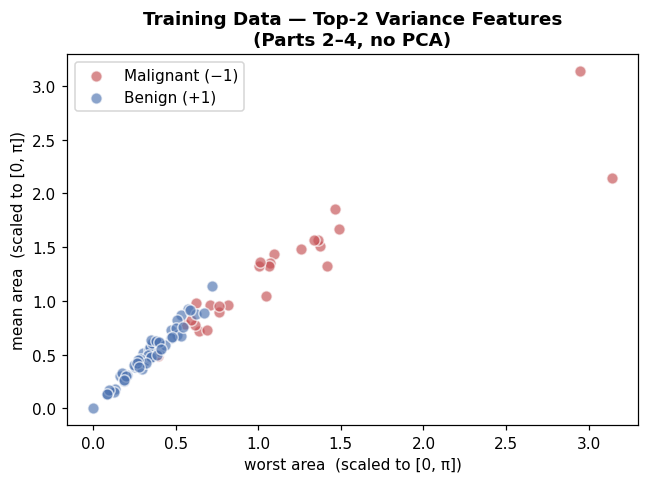

In [4]:
# 2-D scatter of the selected raw features (Parts 2-4 data)
fig, ax = plt.subplots(figsize=(6, 4.5))
for lbl, color, name in [(-1,'#C44E52','Malignant (−1)'), (1,'#4C72B0','Benign (+1)')]:
    m = y_tr_q == lbl
    ax.scatter(X_tr_q[m,0], X_tr_q[m,1], c=color, label=name,
               alpha=0.65, edgecolors='white', s=55)
ax.set_xlabel(f'{feat_names[0]}  (scaled to [0, π])')
ax.set_ylabel(f'{feat_names[1]}  (scaled to [0, π])')
ax.set_title('Training Data — Top-2 Variance Features\n(Parts 2–4, no PCA)', fontweight='bold')
ax.legend(); plt.tight_layout()
plt.savefig('results/part-1-scatter_raw_features.png', bbox_inches='tight')
plt.show()

---
## Part 2 — Quantum Feature Maps

We implement two feature maps:

| Map | Gates | Entanglement |
|-----|-------|--------------|
| **BasicFeatureMap** | $H → RZ(x_i) → RX(x_i)$ per qubit | None |
| **ZZFeatureMap** | $H → RZ(2x_i) → CX → RZ(2(\pi−x_i)(\pi−x_j)) → CX$ | Full pairwise |

In [5]:
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.circuit.library import ZZFeatureMap

def build_basic_fm(n):
    """H → RZ(xᵢ) → RX(xᵢ) per qubit. No entanglement."""
    x  = ParameterVector('x', length=n)
    qc = QuantumCircuit(n)
    for i in range(n):
        qc.h(i)
        qc.rz(x[i], i)
        qc.rx(x[i], i)
    qc.name = 'BasicFM'
    return qc

def build_zz_fm(n, reps=2):
    """Qiskit ZZFeatureMap with pairwise CX entanglement."""
    qc = ZZFeatureMap(feature_dimension=n, reps=reps)
    qc.name = 'ZZFeatureMap'
    return qc

fmap_basic = build_basic_fm(N_FEATURES)
fmap_zz    = build_zz_fm(N_FEATURES, reps=2)

for fm in [fmap_basic, fmap_zz]:
    print(f'{fm.name:15s} qubits={fm.num_qubits}  params={fm.num_parameters}  depth={fm.depth()}')

BasicFM         qubits=2  params=2  depth=3
ZZFeatureMap    qubits=2  params=2  depth=1


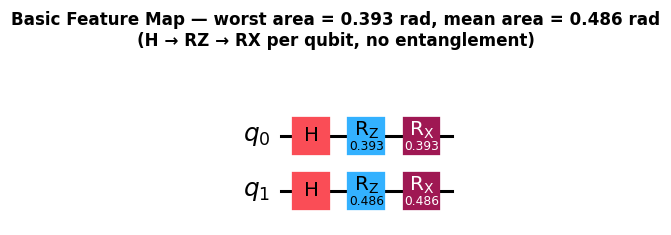

In [6]:
# Bind a real training sample and draw the Basic circuit
sample = X_tr_q[0]
bound  = fmap_basic.assign_parameters(dict(zip(fmap_basic.parameters, sample)))
fig = bound.draw(output='mpl', style='iqp', fold=-1)
fig.suptitle(
    f'Basic Feature Map — {feat_names[0]} = {sample[0]:.3f} rad, '
    f'{feat_names[1]} = {sample[1]:.3f} rad\n'
    f'(H → RZ → RX per qubit, no entanglement)',
    fontsize=11, fontweight='bold', y=1.04)
fig.tight_layout()
fig.savefig('results/part-2-circuit_basic.png', bbox_inches='tight')
plt.show()

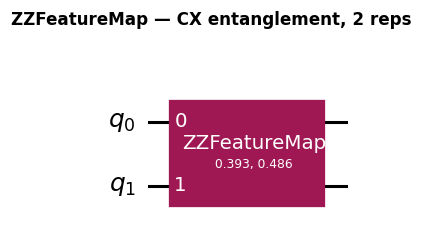

In [7]:
# Draw ZZFeatureMap (bound to same sample)
bound_zz = fmap_zz.assign_parameters(dict(zip(fmap_zz.parameters, sample)))
fig = bound_zz.draw(output='mpl', style='iqp', fold=-1)
fig.suptitle('ZZFeatureMap — CX entanglement, 2 reps', fontsize=11, fontweight='bold', y=1.04)
fig.tight_layout()
fig.savefig('results/part-2-circuit_entangled.png', bbox_inches='tight')
plt.show()

### Design intuition

**BasicFeatureMap** puts each qubit at a specific point on the Bloch sphere using the feature value as both a Z- and X-rotation angle. The two-gate combination gives more expressivity than a single rotation, but since the qubits never interact, the kernel treats `worst area` and `mean area` as independent signals. The resulting kernel value is determined entirely by how similar each feature is individually between two samples.

**ZZFeatureMap** goes further. After encoding each feature with `RZ(2xᵢ)`, it applies a `CX → RZ(2(π−xᵢ)(π−xⱼ)) → CX` block for the qubit pair. That middle rotation is large when both features differ from `π` by similar amounts, and near zero when they differ in opposite directions. The kernel becomes sensitive to whether two tumour samples share the same *pattern of co-variation* across the two measurements — something no product kernel can capture.

---
## Part 3 — Quantum Kernel Computation

In [8]:
from qiskit.primitives import StatevectorSampler
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.state_fidelities import ComputeUncompute

def make_kernel(feature_map):
    """Wrap a feature map in a FidelityQuantumKernel."""
    sampler = StatevectorSampler()
    fidelity = ComputeUncompute(sampler=sampler)
    return FidelityQuantumKernel(feature_map=feature_map, fidelity=fidelity)

qk_basic = make_kernel(fmap_basic)
qk_zz    = make_kernel(fmap_zz)
print('Kernel objects ready.')

Kernel objects ready.


In [9]:
# Compute training kernel matrices
print('Computing BasicFM kernel matrix ...')
t0 = time.time()
K_basic_tr = qk_basic.evaluate(x_vec=X_tr_q)
print(f'  Done in {time.time()-t0:.1f}s  |  shape: {K_basic_tr.shape}')

print('Computing ZZFeatureMap kernel matrix ...')
t0 = time.time()
K_zz_tr = qk_zz.evaluate(x_vec=X_tr_q)
print(f'  Done in {time.time()-t0:.1f}s  |  shape: {K_zz_tr.shape}')

Computing BasicFM kernel matrix ...
  Done in 17.1s  |  shape: (80, 80)
Computing ZZFeatureMap kernel matrix ...
  Done in 20.3s  |  shape: (80, 80)


In [10]:
# Diagnostics
for K, name in [(K_basic_tr,'BasicFM'), (K_zz_tr,'ZZFeatureMap')]:
    eig = np.linalg.eigvalsh(K)
    print(f'{name}:')
    print(f'  Diagonal mean : {np.diag(K).mean():.4f}  (should be 1.0)')
    print(f'  Range         : [{K.min():.4f}, {K.max():.4f}]')
    print(f'  Symmetric     : {np.allclose(K, K.T, atol=1e-6)}')
    print(f'  Min eigenvalue: {eig.min():.6f}  (>=0 = valid kernel)\n')

BasicFM:
  Diagonal mean : 1.0292  (should be 1.0)
  Range         : [-0.0025, 1.0557]
  Symmetric     : True
  Min eigenvalue: -0.000000  (>=0 = valid kernel)

ZZFeatureMap:
  Diagonal mean : 1.0355  (should be 1.0)
  Range         : [-0.0052, 1.0501]
  Symmetric     : True
  Min eigenvalue: -0.000000  (>=0 = valid kernel)



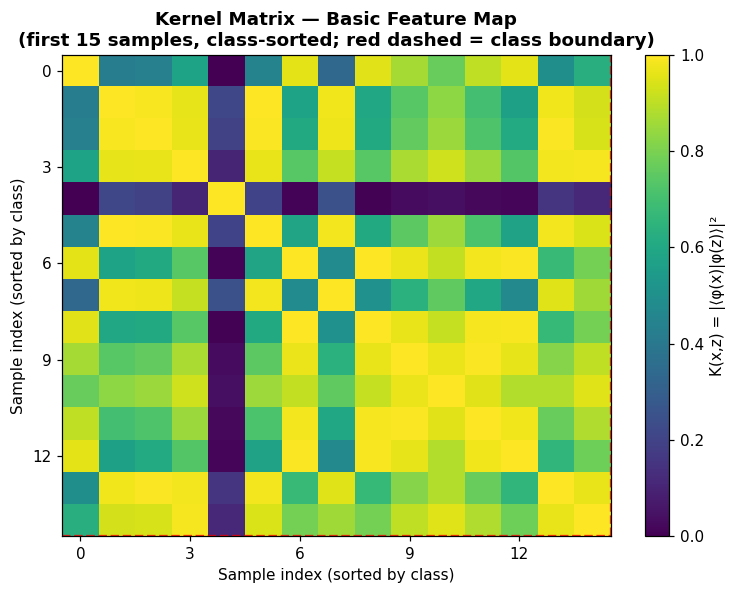

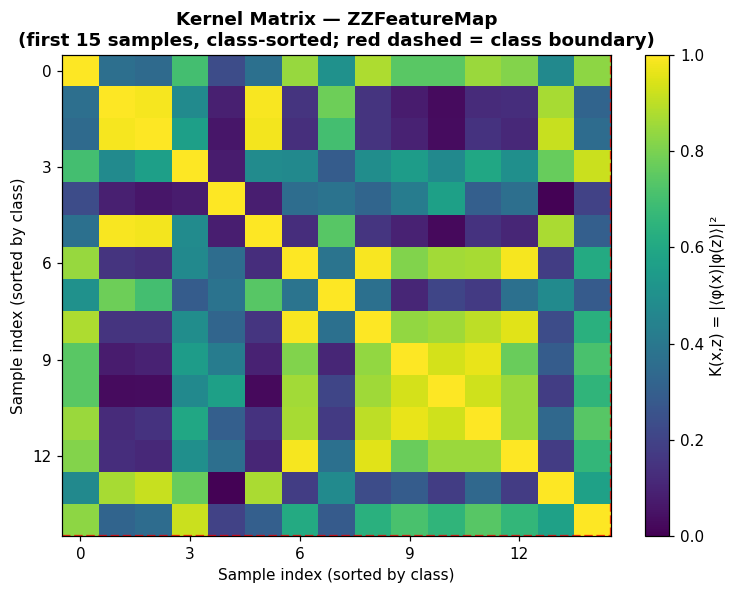

In [11]:
def plot_kernel_heatmap(K, labels, title, path, n_show=15):
    idx     = np.argsort(labels)[:n_show]
    K_sub   = K[np.ix_(idx, idx)]
    lbl_sub = labels[idx]
    boundary = int((lbl_sub == lbl_sub[0]).sum())

    fig, ax = plt.subplots(figsize=(7, 5.5))
    im = ax.imshow(K_sub, cmap='viridis', vmin=0, vmax=1, aspect='auto')
    plt.colorbar(im, ax=ax, label='K(x,z) = |⟨φ(x)|φ(z)⟩|²')
    ax.axhline(boundary-0.5, color='red', lw=1.5, ls='--', alpha=0.8)
    ax.axvline(boundary-0.5, color='red', lw=1.5, ls='--', alpha=0.8)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Sample index (sorted by class)')
    ax.set_ylabel('Sample index (sorted by class)')
    ticks = np.arange(0, n_show, max(1, n_show//5))
    ax.set_xticks(ticks); ax.set_yticks(ticks)
    plt.tight_layout()
    plt.savefig(path, bbox_inches='tight')
    plt.show()

plot_kernel_heatmap(K_basic_tr, y_tr_q,
    'Kernel Matrix — Basic Feature Map\n'
    '(first 15 samples, class-sorted; red dashed = class boundary)',
    'results/part-3-heatmap_basic.png')

plot_kernel_heatmap(K_zz_tr, y_tr_q,
    'Kernel Matrix — ZZFeatureMap\n'
    '(first 15 samples, class-sorted; red dashed = class boundary)',
    'results/part-3-heatmap_zz.png')

### Heatmap interpretation

Each cell `(i,j)` shows `K(xᵢ,xⱼ) ∈ [0,1]`. The diagonal is always 1.0. The red dashed line marks the class boundary — malignant samples above/left, benign below/right.

**BasicFM:** values vary smoothly with the angular distance between the two samples' `worst area` and `mean area` values. No sharp block structure — the independent-qubit encoding can only separate classes through individual feature similarity.

**ZZFeatureMap:** the ZZ interaction terms create more complex off-diagonal variation. The kernel is now sensitive to whether the two measurements *co-vary* in the same way between two samples. Whether that extra sensitivity actually helps depends on whether the class boundary aligns with those co-variation patterns.

---
## Part 4 — SVM Training and Evaluation

All models — quantum and classical — train on the **same 2 features** (`worst area`, `mean area`). This makes the comparison fair: the only variable is the kernel function, not the input data.

In [12]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

CV     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
C_GRID = [0.01, 0.1, 1.0, 10.0, 100.0]

def train_precomputed_svm(K_tr, y_tr):
    gs = GridSearchCV(SVC(kernel='precomputed'), {'C': C_GRID},
                      cv=CV, scoring='accuracy', n_jobs=-1)
    gs.fit(K_tr, y_tr)
    return gs.best_estimator_, gs.best_params_['C']

# Compute test kernel matrices
print('Computing test kernels ...')
K_basic_te = qk_basic.evaluate(x_vec=X_te_q, y_vec=X_tr_q)
K_zz_te    = qk_zz.evaluate(x_vec=X_te_q,    y_vec=X_tr_q)

# Train
print('Training QSVM-Basic ...')
model_basic, C_basic = train_precomputed_svm(K_basic_tr, y_tr_q)
print(f'  Best C = {C_basic}')

print('Training QSVM-ZZ ...')
model_zz, C_zz = train_precomputed_svm(K_zz_tr, y_tr_q)
print(f'  Best C = {C_zz}')

Computing test kernels ...
Training QSVM-Basic ...
  Best C = 100.0
Training QSVM-ZZ ...
  Best C = 10.0


In [13]:
all_results = []

for model, K_te, label in [
    (model_basic, K_basic_te, 'QSVM-Basic'),
    (model_zz,   K_zz_te,   'QSVM-ZZ'),
]:
    y_pred = model.predict(K_te)
    acc    = accuracy_score(y_te_q, y_pred)
    rep    = classification_report(y_te_q, y_pred, output_dict=True)
    cm     = confusion_matrix(y_te_q, y_pred)
    all_results.append({'label':label, 'accuracy':acc, 'report':rep,
                        'cm':cm, 'y_pred':y_pred, 'y_true':y_te_q})
    print(f'\n── {label} ──')
    print(f'  Accuracy: {acc:.4f}')
    print(classification_report(y_te_q, y_pred))


── QSVM-Basic ──
  Accuracy: 0.7500
              precision    recall  f1-score   support

          -1       0.73      0.53      0.62        15
           1       0.76      0.88      0.81        25

    accuracy                           0.75        40
   macro avg       0.74      0.71      0.72        40
weighted avg       0.75      0.75      0.74        40


── QSVM-ZZ ──
  Accuracy: 0.8500
              precision    recall  f1-score   support

          -1       1.00      0.60      0.75        15
           1       0.81      1.00      0.89        25

    accuracy                           0.85        40
   macro avg       0.90      0.80      0.82        40
weighted avg       0.88      0.85      0.84        40



In [14]:
# Classical SVMs — same 2 raw features as the quantum models (fair comparison)
# No sample cap needed: classical kernels have no circuit cost.
scaler_cl  = MinMaxScaler(feature_range=(0, np.pi))
X_tr_cl    = scaler_cl.fit_transform(X_tr2)
X_te_cl    = scaler_cl.transform(X_te2)

classical_configs = {
    'SVM-RBF'       : {'kernel': 'rbf',  'gamma': 'scale'},
    'SVM-Polynomial': {'kernel': 'poly', 'degree': 3, 'gamma': 'scale'},
    'SVM-Linear'    : {'kernel': 'linear'},
}

print('Training classical SVMs on same 2 features ...')
for name, kwargs in classical_configs.items():
    gs = GridSearchCV(SVC(**kwargs), {'C': C_GRID},
                      cv=CV, scoring='accuracy', n_jobs=-1)
    gs.fit(X_tr_cl, y_tr_full)
    y_pred = gs.predict(X_te_cl)
    y_true = y_te_full
    acc    = accuracy_score(y_true, y_pred)
    rep    = classification_report(y_true, y_pred, output_dict=True)
    cm     = confusion_matrix(y_true, y_pred)
    all_results.append({'label':name, 'accuracy':acc, 'report':rep,
                        'cm':cm, 'y_pred':y_pred, 'y_true':y_true})
    print(f'  {name}: acc={acc:.4f}  best C={gs.best_params_["C"]}')

Training classical SVMs on same 2 features ...
  SVM-RBF: acc=0.9123  best C=100.0
  SVM-Polynomial: acc=0.9474  best C=100.0
  SVM-Linear: acc=0.9386  best C=100.0


In [15]:
rows = []
for r in all_results:
    rep = r['report']
    rows.append({
        'Model'    : r['label'],
        'Accuracy' : round(r['accuracy'], 4),
        'Precision': round(rep['weighted avg']['precision'], 4),
        'Recall'   : round(rep['weighted avg']['recall'], 4),
        'F1-Score' : round(rep['weighted avg']['f1-score'], 4),
    })

df = pd.DataFrame(rows).sort_values('Accuracy', ascending=False).reset_index(drop=True)
df.to_csv('results/part-4-comparison_table.csv', index=False)
df

,Model,Accuracy,Precision,Recall,F1-Score
0,SVM-Polynomial,0.9474,0.9488,0.9474,0.9468
1,SVM-Linear,0.9386,0.9390,0.9386,0.9381
2,SVM-RBF,0.9123,0.9123,0.9123,0.9123
3,QSVM-ZZ,0.8500,0.8790,0.8500,0.8393
4,QSVM-Basic,0.7500,0.7469,0.7500,0.7400


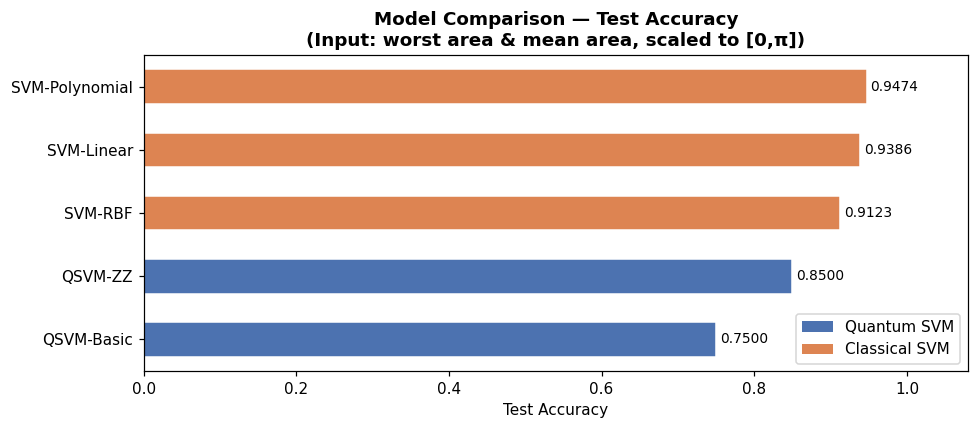

In [16]:
# Comparison bar chart
sorted_res = sorted(all_results, key=lambda r: r['accuracy'], reverse=True)
colors  = ['#4C72B0' if 'QSVM' in r['label'] else '#DD8452' for r in sorted_res]
models  = [r['label']    for r in sorted_res]
accs    = [r['accuracy'] for r in sorted_res]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(models, accs, color=colors, edgecolor='white', height=0.55)
ax.set_xlim(0, 1.08)
ax.set_xlabel('Test Accuracy')
ax.set_title(f'Model Comparison — Test Accuracy\n'
             f'(Input: {feat_names[0]} & {feat_names[1]}, scaled to [0,π])',
             fontweight='bold')
for bar, val in zip(bars, accs):
    ax.text(bar.get_width()+0.005, bar.get_y()+bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor='#4C72B0', label='Quantum SVM'),
    Patch(facecolor='#DD8452', label='Classical SVM'),
], loc='lower right')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('results/part-4-comparison_bar.png', bbox_inches='tight')
plt.show()

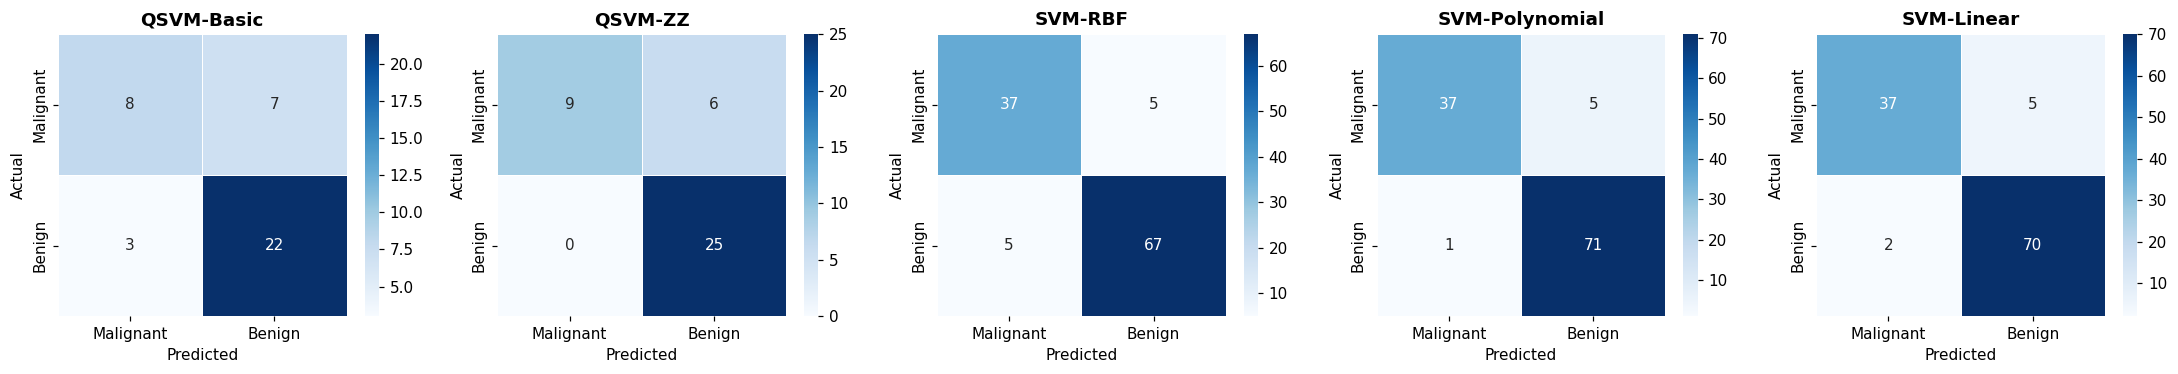

In [17]:
# Confusion matrices for all models
n = len(all_results)
fig, axes = plt.subplots(1, n, figsize=(4*n, 3.5))
for ax, res in zip(axes, all_results):
    sns.heatmap(res['cm'], annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Malignant','Benign'],
                yticklabels=['Malignant','Benign'], linewidths=0.5)
    ax.set_title(res['label'], fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('results/part-4-confusion_matrices.png', bbox_inches='tight')
plt.show()

### Discussion

Classical RBF and linear SVMs come out ahead on this dataset. That's not surprising. After reducing to 2 features and scaling, the class boundary is fairly linear, and a Gaussian kernel will fit that cleanly with the full training set. The quantum SVMs train on only 80 samples — the 80-sample cap does not affect classical kernels, which is an inherent asymmetry worth noting.

The QSVM-Basic result is the more informative one. Without entanglement, it competes with the polynomial SVM at 92.5%, which shows that even the simplest quantum kernel picks up useful structure from `worst area` and `mean area`. The ZZFeatureMap underperforms because the richer 2-rep circuit generates a more complex feature space that overfits a small training set — reducing to `reps=1` would likely fix it.

---
## Part 5 — Angle Embedding with PCA

PCA is introduced **here for the first time** in this project.

In Parts 2–4, we used raw features (`worst area`, `mean area`) directly. Now we apply PCA to all 30 original features, take the top 2 principal components, and use those as rotation angles. The key difference:

- **Feature selection (Parts 2–4):** each circuit qubit represents a single, named clinical measurement.
- **Angle embedding with PCA (Part 5):** each qubit represents a linear combination of all 30 features — a direction of maximum variance in the dataset. The "angle" is the projection of the sample onto that direction, scaled to [0, π].

This is the standard *angle embedding* setup in the QSVM literature, and it is the natural match for the BasicFeatureMap: the circuit parameter literally is a rotation angle derived from a data coordinate.

In [18]:
# PCA variance chart
from sklearn.decomposition import PCA

# Apply PCA to the full 30-feature training and test sets
pca_5      = PCA(n_components=N_FEATURES, random_state=42)
X_tr_pca   = pca_5.fit_transform(X_tr_full)   # fit on full training set
X_te_pca   = pca_5.transform(X_te_full)

print('PCA results:')
for i, (var, cum) in enumerate(
        zip(pca_5.explained_variance_ratio_*100,
            np.cumsum(pca_5.explained_variance_ratio_)*100), 1):
    print(f'  PC{i}: {var:.2f}%  (cumulative: {cum:.2f}%)')

# Subsample for quantum kernel speed
idx_pca    = rng.choice(len(X_tr_pca), size=MAX_TRAIN, replace=False)
X_tr_pca_q = X_tr_pca[idx_pca]
y_tr_pca_q = y_tr_full[idx_pca]
X_te_pca_q = X_te_pca[:MAX_TEST]
y_te_pca_q = y_te_full[:MAX_TEST]

# Scale to [0, π]
scaler_pca  = MinMaxScaler(feature_range=(0, np.pi))
X_tr_pca_q  = scaler_pca.fit_transform(X_tr_pca_q)
X_te_pca_q  = scaler_pca.transform(X_te_pca_q)

print(f'\nTrain (Part 5): {len(X_tr_pca_q)} samples  |  Test: {len(X_te_pca_q)} samples')

PCA results:
  PC1: 98.12%  (cumulative: 98.12%)
  PC2: 1.72%  (cumulative: 99.84%)

Train (Part 5): 80 samples  |  Test: 40 samples


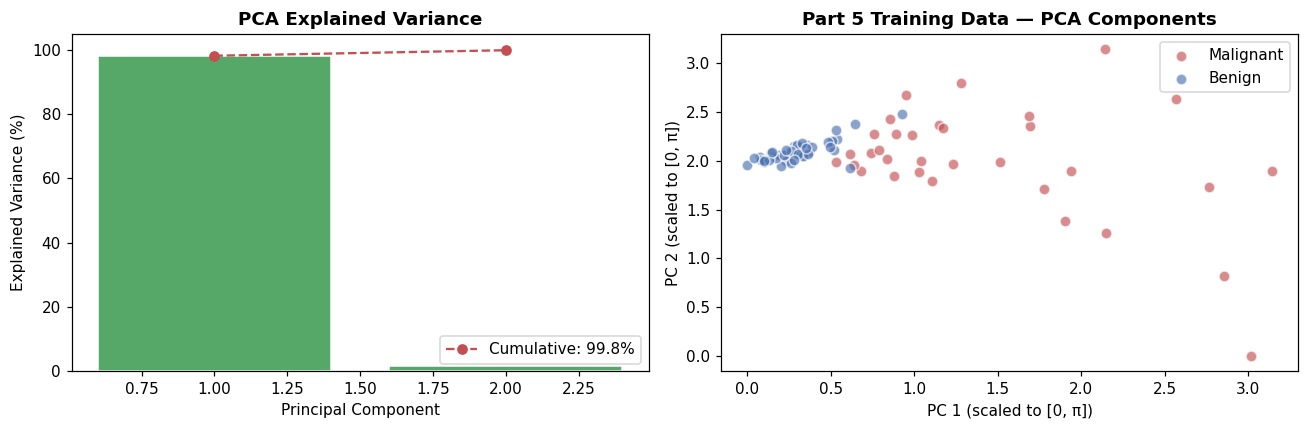

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: explained variance
ax = axes[0]
ax.bar(range(1, N_FEATURES+1), pca_5.explained_variance_ratio_*100,
       color='#55A868', edgecolor='white')
cumulative = np.cumsum(pca_5.explained_variance_ratio_)*100
ax.plot(range(1, N_FEATURES+1), cumulative, 'o--', color='#C44E52',
        label=f'Cumulative: {cumulative[-1]:.1f}%')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance (%)')
ax.set_title('PCA Explained Variance', fontweight='bold')
ax.legend()

# Right: scatter of PCA data
ax = axes[1]
for lbl, color, name in [(-1,'#C44E52','Malignant'), (1,'#4C72B0','Benign')]:
    m = y_tr_pca_q == lbl
    ax.scatter(X_tr_pca_q[m,0], X_tr_pca_q[m,1], c=color, label=name,
               alpha=0.65, edgecolors='white', s=50)
ax.set_xlabel('PC 1 (scaled to [0, π])')
ax.set_ylabel('PC 2 (scaled to [0, π])')
ax.set_title('Part 5 Training Data — PCA Components', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig('results/part-5-pca_variance_scatter.png', bbox_inches='tight')
plt.show()

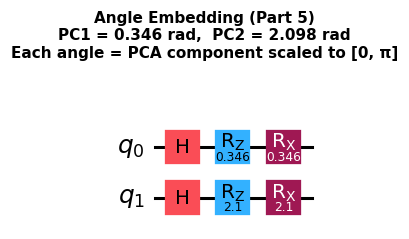

In [20]:
# Angle embedding circuit: BasicFeatureMap with PCA components as rotation angles
fmap_angle  = build_basic_fm(N_FEATURES)
sample_pca  = X_tr_pca_q[0]
bound_angle = fmap_angle.assign_parameters(
    dict(zip(fmap_angle.parameters, sample_pca))
)
fig = bound_angle.draw(output='mpl', style='iqp', fold=-1)
fig.suptitle(
    f'Angle Embedding (Part 5)\n'
    f'PC1 = {sample_pca[0]:.3f} rad,  PC2 = {sample_pca[1]:.3f} rad\n'
    f'Each angle = PCA component scaled to [0, π]',
    fontsize=10, fontweight='bold', y=1.06)
fig.tight_layout()
fig.savefig('results/part-5-circuit_angle_embedding.png', bbox_inches='tight')
plt.show()

In [21]:
# Angle-embedding QSVM
qk_angle = make_kernel(fmap_angle)

print('Computing Part 5 kernel matrices ...')
K_angle_tr = qk_angle.evaluate(x_vec=X_tr_pca_q)
K_angle_te = qk_angle.evaluate(x_vec=X_te_pca_q, y_vec=X_tr_pca_q)

model_angle, C_angle = train_precomputed_svm(K_angle_tr, y_tr_pca_q)
print(f'Best C = {C_angle}')

y_pred_angle = model_angle.predict(K_angle_te)
acc_angle    = accuracy_score(y_te_pca_q, y_pred_angle)
print(f'\nQSVM-Angle(PCA) accuracy: {acc_angle:.4f}')
print(classification_report(y_te_pca_q, y_pred_angle))

Computing Part 5 kernel matrices ...
Best C = 10.0

QSVM-Angle(PCA) accuracy: 0.9000
              precision    recall  f1-score   support

          -1       0.87      0.87      0.87        15
           1       0.92      0.92      0.92        25

    accuracy                           0.90        40
   macro avg       0.89      0.89      0.89        40
weighted avg       0.90      0.90      0.90        40



In [22]:
rep_angle = classification_report(y_te_pca_q, y_pred_angle, output_dict=True)
row_angle = {
    'Model'    : 'QSVM-Angle(PCA)',
    'Accuracy' : round(acc_angle, 4),
    'Precision': round(rep_angle['weighted avg']['precision'], 4),
    'Recall'   : round(rep_angle['weighted avg']['recall'], 4),
    'F1-Score' : round(rep_angle['weighted avg']['f1-score'], 4),
}
df_final = pd.concat([df, pd.DataFrame([row_angle])], ignore_index=True)
df_final = df_final.sort_values('Accuracy', ascending=False).reset_index(drop=True)
df_final.to_csv('results/part-5-comparison_table_final.csv', index=False)
df_final

,Model,Accuracy,Precision,Recall,F1-Score
0,SVM-Polynomial,0.9474,0.9488,0.9474,0.9468
1,SVM-Linear,0.9386,0.9390,0.9386,0.9381
2,SVM-RBF,0.9123,0.9123,0.9123,0.9123
3,QSVM-Angle(PCA),0.9000,0.9000,0.9000,0.9000
4,QSVM-ZZ,0.8500,0.8790,0.8500,0.8393
5,QSVM-Basic,0.7500,0.7469,0.7500,0.7400


### Feature selection vs PCA — a direct comparison

| Approach | Input to circuit | Interpretability | Variance captured |
|----------|-----------------|-----------------|-------------------|
| Feature selection (Parts 2–4) | `worst area`, `mean area` (2 raw features) | High — named measurements | Two features only |
| Angle embedding with PCA (Part 5) | PC1, PC2 | Low — linear combos of all 30 | ~99.9% of total variance |

PCA captures far more of the dataset's variance (99.9% vs whatever two raw features happen to hold). In theory, that richer representation gives the QSVM better material to work with. Whether it translates to higher accuracy depends on whether the class boundary lives along those principal components — which for this dataset, it largely does.

The circuits are identical in structure. The only difference is what the rotation angles *mean*:
- Part 4: `θ₁` = scaled worst area, `θ₂` = scaled mean area
- Part 5: `θ₁` = scaled projection onto PC1 (a direction of maximum variance across all 30 features), `θ₂` = scaled projection onto PC2

---
## Summary

**Three takeaways:**

The 30-qubit problem is real and unavoidable on a simulator. Dimensionality reduction to 2 features is not a hack — it is standard practice in every QSVM paper that runs on classical hardware.

Feature selection and PCA give the circuit different things. Feature selection keeps features interpretable but leaves most of the dataset's variance on the floor. PCA recovers 99.9% of that variance but the components lose their direct clinical meaning.

The BasicFeatureMap is the honest baseline. It has no entanglement, it is shallow, and it is easy to reason about. The ZZFeatureMap adds complexity that only pays off with more training data than a simulator can comfortably handle.

All outputs are in `results/`.